In [1]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
######################## Define the text size of each plot globally ###########
SMALL_SIZE = 10
BIGGER_SIZE = 10

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["font.family"] = "Arial"
######################## Define the text size of each plot globally ###########

In [3]:
df = pd.read_excel(r'..\\data\10_summary.xlsx')

In [4]:
df

,Parameter,Unit,P1,P2,P3,P4,P5,ML
0,E50ref,kPa,20541.0000,18467.166200,25000.00,23200.000000,20000.0000,21022.871000
1,Eoedref,kPa,21000.0000,21138.749577,25000.00,31800.000000,17500.0000,22091.441000
2,Eurref,kPa,82024.0000,63416.248731,75000.00,78900.000000,70000.0000,87476.070000
3,φ',°,37.0000,36.900000,36.70,37.000000,36.0000,35.452000
4,ψ',°,9.0000,8.600000,9.00,8.000000,10.0000,7.445000
5,c'ref,kPa,0.0000,0.000000,1.00,0.000000,2.0000,0.000000
6,m,-,0.5000,0.700000,0.60,0.720000,0.5000,0.680000
7,ν_ur,-,0.2000,0.200000,0.20,0.200000,0.2000,0.109000
8,Rf,-,0.9000,0.900000,0.92,0.900000,0.9000,0.889000
9,K0NC,-,0.3982,0.400000,0.40,0.398185,0.4122,0.392000


In [5]:
ML = pd.DataFrame(df.iloc[:,-1])

In [6]:
ML 

,ML
0,21022.871000
1,22091.441000
2,87476.070000
3,35.452000
4,7.445000
5,0.000000
6,0.680000
7,0.109000
8,0.889000
9,0.392000


In [7]:
df = df.iloc[:, 0:7]

In [8]:
df

,Parameter,Unit,P1,P2,P3,P4,P5
0,E50ref,kPa,20541.0000,18467.166200,25000.00,23200.000000,20000.0000
1,Eoedref,kPa,21000.0000,21138.749577,25000.00,31800.000000,17500.0000
2,Eurref,kPa,82024.0000,63416.248731,75000.00,78900.000000,70000.0000
3,φ',°,37.0000,36.900000,36.70,37.000000,36.0000
4,ψ',°,9.0000,8.600000,9.00,8.000000,10.0000
5,c'ref,kPa,0.0000,0.000000,1.00,0.000000,2.0000
6,m,-,0.5000,0.700000,0.60,0.720000,0.5000
7,ν_ur,-,0.2000,0.200000,0.20,0.200000,0.2000
8,Rf,-,0.9000,0.900000,0.92,0.900000,0.9000
9,K0NC,-,0.3982,0.400000,0.40,0.398185,0.4122


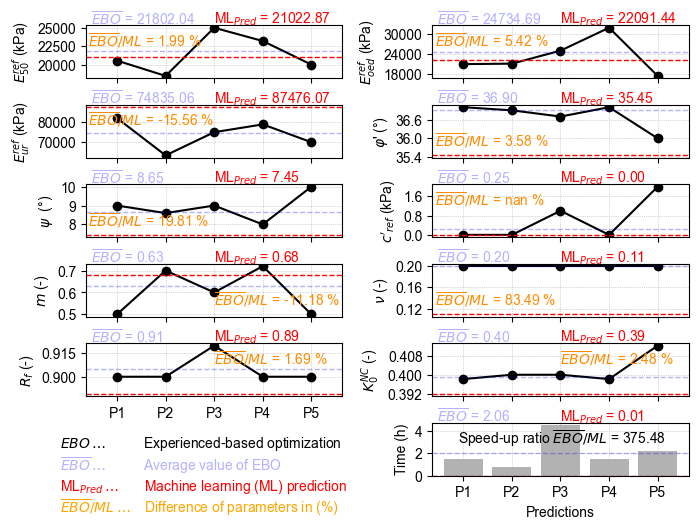

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

# Assuming df and ML are already defined

# Define plot structure
nrows = 6 
ncols = 2
cm = 1/2.54  # centimeters in inches
figsize = (17.4*cm, 13*cm)

# Create subplots for each parameter
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True)
parameters = df['Parameter']

parameters_plot = ['$E_{50}^{ref}$ (kPa)', '$E_{oed}^{ref}$ (kPa)', '$E_{ur}^{ref}$ (kPa)', 
                      "$\\varphi$' (°)",'$\psi$  (°)', "$c'_{ref}$ (kPa)",
                      '${m}$ (-)', '${ν}$ (-)', 
                      '${R_f}$ (-)', '$K_0^{NC}$ (-)','$p^{ref}$  (kPa)', 'Time (h)']

colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

# Columns to include in the average calculation
average_columns = df.columns[2:6]

# Flatten the 2D array of axes to iterate easily
axs = axs.flatten()

x_value = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.5, 0.01, 0.5, 0.5, 0.5, 0.1]
y_value = [0.9, 0.9, 0.9, 0.5, 0.5, 0.9, 0.5, 0.5, 0.9, 0.9, 0.9, 0.9]

# Plot each parameter in a separate subplot
for i, ax in enumerate(axs[:len(parameters)]):
    if i < len(parameters)-2:  # Plot everything except the second-to-last plot
        ax.plot(df.columns[2:], df.iloc[i, 2:], label=parameters[i], color='k', marker='o')

        average_value = np.average(df[average_columns].iloc[i])
        ax.axhline(average_value, color='b', linestyle='--', label='Average', alpha = 0.3, lw = 1.0)
        ax.text(0.02, 1.3, s = '$\\overline{EBO}$'+f' = {average_value:.2f}', color = 'b', transform=ax.transAxes, ha='left', va='top', alpha = 0.3)

        ax.axhline(ML.iloc[i, 0], color='r', linestyle='--', label='ML', lw = 1.0)
        ax.text(0.5, 1.28, s = 'ML$_{Pred}$'+f' = {ML.iloc[i, 0]:.2f}', color = 'r', transform=ax.transAxes, ha='left', va='top',)

        ax.text(x_value[i], y_value[i], s = '$\\overline{EBO} / ML$'+f' = {np.average(((df.iloc[i, 2:] / ML.iloc[i, 0]) * 100 - 100)):.2f} %', color = 'darkorange', transform=ax.transAxes, ha='left', va='top',)

    elif i == len(parameters)-1:  # Plot the last one
        ax.bar(df.columns[2:], df.iloc[i, 2:], label=parameters[i], color='grey', alpha=0.6)

        average_value = np.average(df[average_columns].iloc[i])
        ax.axhline(average_value, color='b', linestyle='--', label='Average', alpha = 0.3, lw = 1.0)
        ax.text(0.02, 1.3, s = '$\\overline{EBO}$'+f' = {average_value:.2f}', color = 'b', transform=ax.transAxes, ha='left', va='top', alpha = 0.3)

        ax.axhline(ML.iloc[i, 0], color='r', linestyle='--', label='ML$_{Pred}$', lw = 1.0)
        ax.text(0.5, 1.28, s = 'ML$_{Pred}$'+f' = {ML.iloc[i, 0]:.2f}', color = 'r', transform=ax.transAxes, ha='left', va='top',)

        ax.text(x_value[i], y_value[i], s = 'Speed-up ratio $\\overline{EBO} / ML$'+f' = {np.average((df.iloc[i, 2:] / ML.iloc[i, 0])):.2f}', color = 'k', transform=ax.transAxes, ha='left', va='top',)

    ax.set_ylabel(parameters_plot[i])
    ax.tick_params(axis='y')
    ax.grid(lw = 0.5, linestyle = 'dotted')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))  # Ensure at least 3 y-ticks

# Re-enable the x-axis for the third-to-last plot
axs[8].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)


# Hide any unused subplots and set the position for text insertion
for j in range(len(parameters), len(axs)):
    fig.delaxes(axs[j])

# Remove the second-to-last subplot and add the text box
fig.delaxes(axs[len(parameters)-2])
text_ax = fig.add_subplot(nrows, ncols, len(parameters)-1)

texts = ["$EBO \dots$         Experienced-based optimization",
"$\\overline{EBO} \dots$         Average value of EBO",
"ML$_{Pred} \dots$      Machine learning (ML) prediction",
"$\\overline{EBO}/ML \dots$   Difference of parameters in (%)"]

y = -0.3
colors = ['black', 'blue', 'r', 'orange']
alphas = [1,0.3,1,1]
for text,color,alpha in zip(texts, colors, alphas):
    text_ax.text(-0.1, 0.9+y, text, va='center', ha='left', color = color, alpha = alpha)
    y = y - 0.4

text_ax.axis('off')

# Set the x-axis label for the bottom row
for ax in axs[-ncols:]:
    ax.set_xlabel('Predictions')

# Adjust layout
plt.subplots_adjust(left=0.11, right=0.99, bottom=0.08, top=0.96, wspace=0.35, hspace=0.5)
plt.savefig(r"../graphics/"+"RealData01_analysis_RealTest_Karlsruhe_200kPa_EBO.png", dpi=1000)
